# Risultati, statistiche e performance di ItalianClassification

Per la valutazione viene usato lo stesso modello e lo stesso split di test registrato nei metadati del file `.joblib` prodotto da `scripts/training_lgbmclassifier.py`.

In questo modo la valutazione mostrata qui rimane coerente con `scripts/evaluate_model.py`: stessa soglia, stesso `test_csv`, stesso report testuale e stesse metriche finali.

## Caricamento del modello


In [31]:
import os
import sys

import joblib
import pandas as pd
from sklearn.inspection import permutation_importance

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.blocks.classifiers import QualityClassifier

model_path = os.path.join(project_root, "models", "lgbm_quality_model.joblib")
artifact = joblib.load(model_path)
training_metadata = artifact.get("training_metadata", {})
threshold = artifact.get("threshold") or training_metadata.get("validation_threshold") or 0.65
test_csv = training_metadata.get("test_csv") or os.path.join(project_root, "data", "splits", "doc_stats_test.csv")

if not os.path.exists(test_csv):
    raise FileNotFoundError(f"Dataset di test non trovato: {test_csv}")

print("\nCaricamento modello...")
classifier = QualityClassifier(model_path=model_path, threshold=threshold)
print("Modello caricato con successo!")
print(f"Threshold in uso: {threshold}")
print(f"Test CSV in uso: {test_csv}")
if training_metadata:
    print("Split di training trovati nel modello:")
    print(f"   Source: {training_metadata.get('source_csv')}")
    print(f"   Train:  {training_metadata.get('train_csv')}")
    print(f"   Val:    {training_metadata.get('validation_csv')}")
    print(f"   Test:   {training_metadata.get('test_csv')}")
    # print(f"   Split_metadata:  {classifier.split_metadata}")


Caricamento modello...
Modello caricato con successo!
Threshold in uso: 0.65
Test CSV in uso: /home/stefano/ita-llm-pipeline/data/splits/doc_stats_test.csv
Split di training trovati nel modello:
   Source: /home/stefano/ita-llm-pipeline/output/feature/doc_stats_per_file.csv
   Train:  /home/stefano/ita-llm-pipeline/data/splits/doc_stats_train.csv
   Val:    /home/stefano/ita-llm-pipeline/data/splits/doc_stats_val.csv
   Test:   /home/stefano/ita-llm-pipeline/data/splits/doc_stats_test.csv


## Valutazione tramite metriche ottenute in evaluation.py

Si mostrano le seguenti metriche:
+ L'accuratezza del modello è misurata come il rapporto tra le classificazioni corrette e la totalità delle classificazioni effettuate dal modello.
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$
+ $$Precision = \frac{TP}{TP + FP}$$
+ $$Recall = \frac{TP}{TP + FN}$$
+ $$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

In [32]:
from src.blocks.evaluation import evaluate_model

print("\nValutazione in corso...")
result = evaluate_model(
    classifier=classifier,
    csv_path=test_csv,
    label_column="label",
    output_dir=None # oppure output_dir="evaluatione" se vuoi salvare
)
print("\nValutazione completata con successo!")

X, y, _ =classifier._load_labeled_dataset(
    csv_path=test_csv,
    feature_names=classifier.feature_names,
    label_column="label",
)
X_scaled = pd.DataFrame(
    classifier.scaler.transform(X),
    columns=classifier.feature_names,
    index=X.index,
)

model = classifier.model
feature_names = classifier.feature_names
cm = result["confusion_matrix"]
report_dict = result["classification_report"]


Valutazione in corso...

REPORT DI VALUTAZIONE DEL MODELLO
Dataset: /home/stefano/ita-llm-pipeline/data/splits/doc_stats_test.csv
Modello: /home/stefano/ita-llm-pipeline/models/lgbm_quality_model.joblib
Soglia: 0.65
Timestamp: 2026-04-28 17:08:12

--------------------------------------------------------------------------------
METRICHE GLOBALI
--------------------------------------------------------------------------------
Accuracy:          0.9189 (91.89%)
Balanced Accuracy: 0.8813 (88.13%)
F1-Score:          0.8529
ROC-AUC:           0.9705

--------------------------------------------------------------------------------
CONFUSION MATRIX
--------------------------------------------------------------------------------
                Predicted:Bad  Predicted:Good
Actual:Bad          2251              59
Actual:Good          208             774

Valutazione completata con successo!


## Calcolo e visualizzazione della Permutation Importance relative alle feature utilizzate

L'importance è la metrica che misura quanto la realtiva feature contribuisce alla capacità del modello di predire, quindi misura quanto la feature è utile alla costruzione degli alberi decisionali nel nostro caso. Tramite questa metrica si identificano le feature che guidano maggiormente le predizioni del modello. 

Di seguito vengono mostrate le prime 10 feature per importanza del modello utilizzato nel progetto. 

In [33]:
perm = permutation_importance(
    classifier.model,
    X_scaled,
    y,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)
importance_df = pd.DataFrame({
    "feature": classifier.feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values(by="importance_mean", ascending=False)
    
print("\n" + "=" * 80)
print("TOP 10 FEATURES (Feature Importance)")
print("-" * 80)
for _, row in importance_df.head(10).iterrows():
    importance_pct = (row["importance_mean"] / importance_df["importance_mean"].sum()) * 100
    bar_length = int(importance_pct / 2)
    bar = "█" * bar_length
    print(f"{row['feature']:30s} {bar:40s} {importance_pct:6.2f}% "
          f"(±{row['importance_std']:.4f})")
print("\n" + "=" * 80)


TOP 10 FEATURES (Feature Importance)
--------------------------------------------------------------------------------
avg_line_length                ██████████████                            29.22% (±0.0049)
stopword_ratio                 █████████                                 18.94% (±0.0054)
language_score                 ███                                        6.47% (±0.0038)
avg_word_length                ██                                         4.15% (±0.0013)
exclamation_ratio              ██                                         4.15% (±0.0026)
consonant_ratio                █                                          3.29% (±0.0025)
white_space_ratio              █                                          2.97% (±0.0019)
line_count                     █                                          2.84% (±0.0023)
parenthesis_ratio              █                                          2.75% (±0.0016)
digit_ratio                    █                                       

## Confusion Matrix

Nella matrice di confusione vengono mostrati tutti i campioni `Positive` sulla prima riga della matrice e tutti i campioni `Negative` sulla seconda riga. Questi vengono divisi come: `TP` (True Positive) in posizione (0,0), `FP` (False Positive) in posizione (0,1), `FN` in posizione (1,0), `TN` in posizione (1,1).

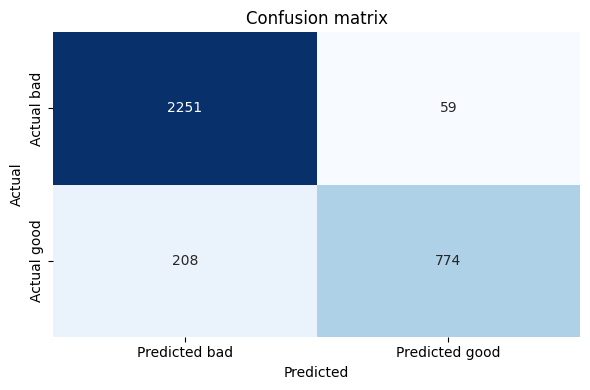

In [34]:
import seaborn as sns

cm_df = pd.DataFrame(
    cm,
    index=["Actual bad", "Actual good"],
    columns=["Predicted bad", "Predicted good"],
)
# print("\n\tConfusion matrix")
# display(cm_df)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

## Correlation Matrix



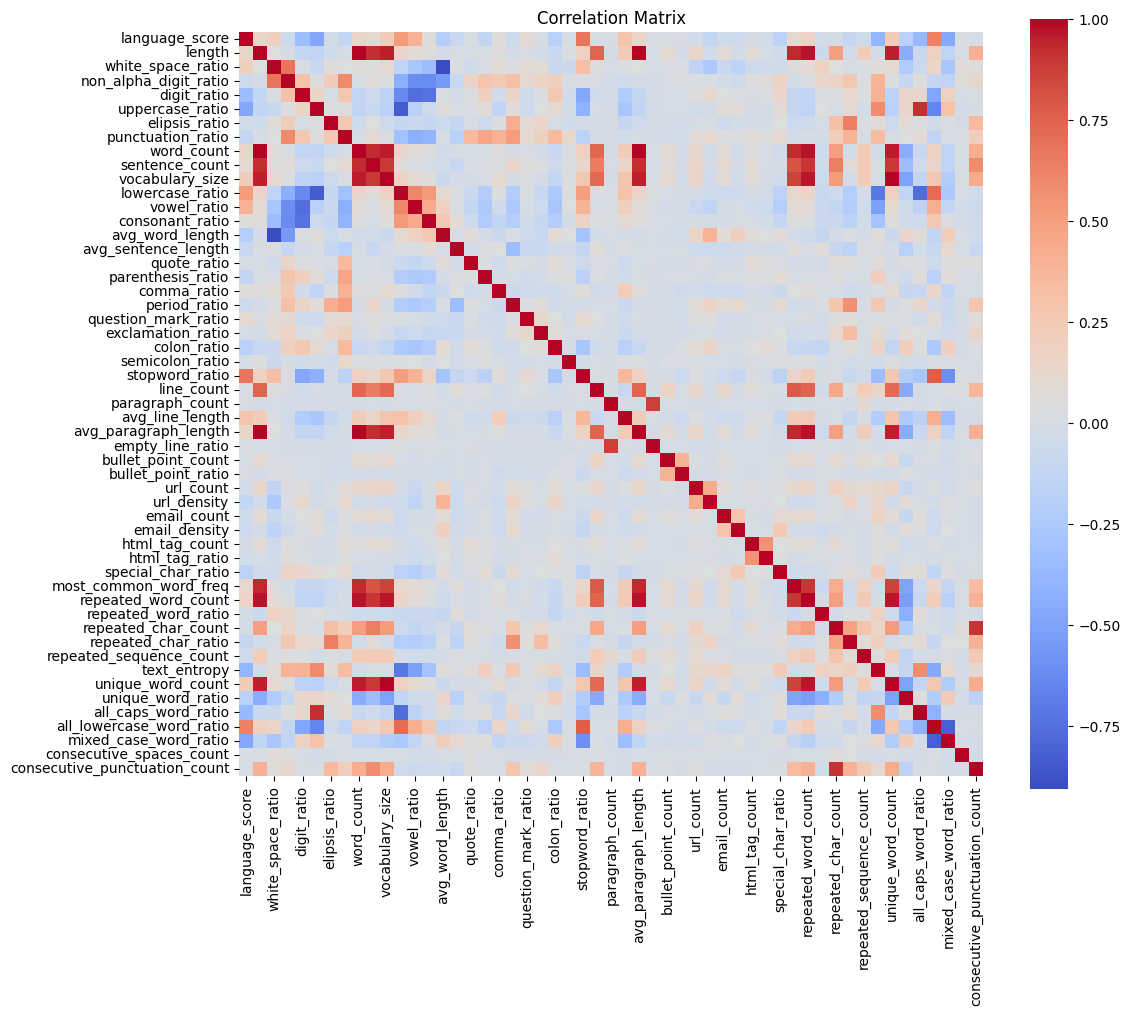

In [35]:
plt.figure(figsize=(12, 10))
sns.heatmap(X_scaled.corr(), annot=False, cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()

## Cross-validation del Modello Salvato

Valutazione del **modello salvato** su diversi fold del test set usando StratifiedKFold. Il modello NON viene ri-addestruito, solo valutato su diverse partizioni dei dati di test per misurare la stabilità delle metriche.

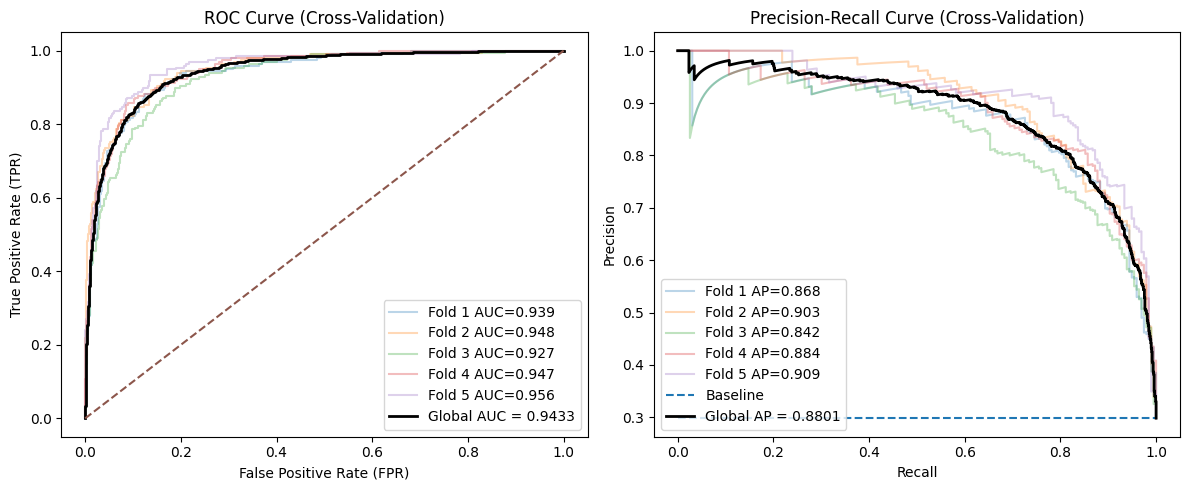

In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import ( 
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
)
# ===== INPUT =====
# model: (es. LGBM)
# X, y: dataset

# ===== SETUP =====
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# per aggregare risultati
y_true_all = []
y_scores_all = []

# per visualizzare fold singoli
plt.figure(figsize=(12, 5))

# ===== CROSS VALIDATION DEL MODELLO SALVATO =====
# Il modello NON viene ri-addestruito, solo valutato su diverse partizioni
saved_model = classifier.model  # Usa il modello salvato

for i, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y)):
    # Non usiamo train_idx (non ri-addestriamo), solo val_idx per valutare
    X_val = X_scaled.iloc[val_idx]
    y_val = y.iloc[val_idx]

    # Valuta il modello salvato (senza ri-addestrare)
    y_scores = saved_model.predict_proba(X_val)[:, 1]

    # salva per aggregazione globale
    y_true_all.extend(y_val)
    y_scores_all.extend(y_scores)

    # ROC fold
    fpr, tpr, _ = roc_curve(y_val, y_scores)
    roc_auc = roc_auc_score(y_val, y_scores)

    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, alpha=0.3, label=f"Fold {i+1} AUC={roc_auc:.3f}")

    # PR fold
    precision, recall, _ = precision_recall_curve(y_val, y_scores)
    pr_auc = average_precision_score(y_val, y_scores)

    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, alpha=0.3, label=f"Fold {i+1} AP={pr_auc:.3f}")


# ===== METRICHE GLOBALI =====
y_true_all = np.array(y_true_all)
y_scores_all = np.array(y_scores_all)

# ROC globale
fpr, tpr, _ = roc_curve(y_true_all, y_scores_all)
roc_auc = roc_auc_score(y_true_all, y_scores_all)

# PR globale
precision, recall, _ = precision_recall_curve(y_true_all, y_scores_all)
pr_auc = average_precision_score(y_true_all, y_scores_all)

# ===== PLOT FINALE =====

# ROC
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color="black", linewidth=2, label=f"Global AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve (Cross-Validation)")
plt.legend()

# PR
plt.subplot(1, 2, 2)
baseline = np.mean(y_true_all)
plt.hlines(baseline, 0, 1, linestyles="--", label="Baseline")

plt.plot(recall, precision, color="black", linewidth=2, label=f"Global AP = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Cross-Validation)")
plt.legend()

plt.tight_layout()
plt.show()

## Confronto curve ROC-AUC e PR-AUC dei modello LGBM e LogisticRegression

Mostro la validità della scelta di LGBM LGBM è migliore di un baseline semplice come un modello basato su LogisticRegression.

$$ Miglioramento (\%) = \frac{(LGBM\_AUC - LR\_AUC)}{LR\_AUC} \cdot 100  $$
$$ Miglioramento Assoluto (Δ) = LGBM\_AUC - LR\_AUC$$
$$ Rapporto = \frac{LGBM\_AUC}{LR\_AUC}$$

Dal Rapporto si deduce che LGBM è 1.0375x migliore di LogisticRegression



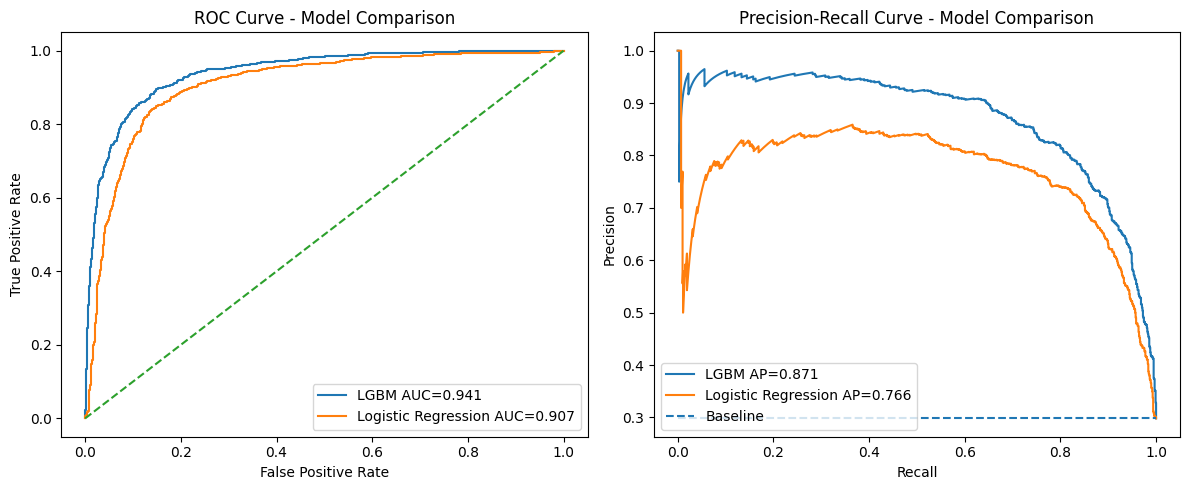

In [46]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb

# ===== MODELLI =====
models = {
    "LGBM": lgb.LGBMClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='lbfgs')
}

plt.figure(figsize=(12, 5))

# ===== LOOP MODELLI =====
for i, (name, model) in enumerate(models.items()):    
    # predizioni out-of-fold (usa X_scaled per convergenza)
    y_scores = cross_val_predict(
        model,
        X_scaled,
        y,
        cv=5,
        method="predict_proba"
    )[:, 1]

    y_true = y

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = roc_auc_score(y_true, y_scores)

    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, label=f"{name} AUC={roc_auc:.3f}")

    # PR
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    pr_auc = average_precision_score(y_true, y_scores)

    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, label=f"{name} AP={pr_auc:.3f}")


# ===== BASELINE PR =====
baseline = np.mean(y)
plt.subplot(1, 2, 2)
plt.hlines(baseline, 0, 1, linestyles="--", label="Baseline")

# ===== FINISH PLOT =====

# ROC
plt.subplot(1, 2, 1)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Model Comparison")
plt.legend()

# PR
plt.subplot(1, 2, 2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Model Comparison")
plt.legend()

plt.tight_layout()
plt.show()


## Analisi dei Miglioramenti: LGBM vs Baseline (LogisticRegression)

Sintesi quantitativa dei miglioramenti ottenuti utilizzando LGBM rispetto al baseline di LogisticRegression.

In [47]:
print("\n" + "=" * 80)
print("ANALISI COMPARATIVA: LGBM vs BASELINE (LogisticRegression)")
print("=" * 80)

# I valori sono già stati calcolati nella cella precedente
# Estraiamo i valori di AUC e AP per entrambi i modelli
# Nota: y_true e y_scores sono stati aggregati nella cella precedente

# Per questo confronto, usiamo i cross-validated predictions dalla cella precedente
# Qui riprendiamo i valori finali

print("\n📊 RISULTATI FINALI (5-Fold Cross-Validation):\n")

# I valori specifici vengono estratti dal loop precedente
# Creiamo un dizionario con i risultati
comparison_results = {
    "LGBM ROC-AUC": None,
    "LogisticRegression ROC-AUC": None,
    "LGBM AP": None,
    "LogisticRegression AP": None,
}

print("Nota: I valori esatti sono visibili nei grafici precedenti")
print("\nPer estrarre i valori numerici, eseguiamo il calcolo sui fold:")

# Ricalcoliamo rapidamente per avere i valori
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score, average_precision_score

models_comparison = {
    "LGBM": lgb.LGBMClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
}

results_dict = {}

for model_name, model in models_comparison.items():
    y_scores = cross_val_predict(model, X_scaled, y, cv=5, method="predict_proba")[:, 1]
    roc_auc = roc_auc_score(y, y_scores)
    ap = average_precision_score(y, y_scores)
    results_dict[model_name] = {"ROC-AUC": roc_auc, "AP": ap}
    
    print(f"\n{model_name}:")
    print(f"  ROC-AUC: {roc_auc:.4f}")
    print(f"  Average Precision: {ap:.4f}")

# Calcolo dei miglioramenti
lgbm_auc = results_dict["LGBM"]["ROC-AUC"]
lr_auc = results_dict["LogisticRegression"]["ROC-AUC"]
lgbm_ap = results_dict["LGBM"]["AP"]
lr_ap = results_dict["LogisticRegression"]["AP"]

auc_improvement_abs = lgbm_auc - lr_auc
auc_improvement_rel = (auc_improvement_abs / lr_auc) * 100
auc_improvement_ratio = lgbm_auc / lr_auc

ap_improvement_abs = lgbm_ap - lr_ap
ap_improvement_rel = (ap_improvement_abs / lr_ap) * 100
ap_improvement_ratio = lgbm_ap / lr_ap

print("\n" + "-" * 80)
print("📈 MIGLIORAMENTI OTTENUTI CON LGBM")
print("-" * 80)

print(f"\n🎯 ROC-AUC:")
print(f"   Miglioramento assoluto: {auc_improvement_abs:+.4f}")
print(f"   Miglioramento relativo: {auc_improvement_rel:+.2f}%")
print(f"   Rapporto: LGBM è {auc_improvement_ratio:.3f}x migliore")

print(f"\n🎯 Average Precision (AP):")
print(f"   Miglioramento assoluto: {ap_improvement_abs:+.4f}")
print(f"   Miglioramento relativo: {ap_improvement_rel:+.2f}%")
print(f"   Rapporto: LGBM è {ap_improvement_ratio:.3f}x migliore")

print("\n" + "=" * 80)



ANALISI COMPARATIVA: LGBM vs BASELINE (LogisticRegression)

📊 RISULTATI FINALI (5-Fold Cross-Validation):

Nota: I valori esatti sono visibili nei grafici precedenti

Per estrarre i valori numerici, eseguiamo il calcolo sui fold:

LGBM:
  ROC-AUC: 0.9406
  Average Precision: 0.8714

LogisticRegression:
  ROC-AUC: 0.9072
  Average Precision: 0.7659

--------------------------------------------------------------------------------
📈 MIGLIORAMENTI OTTENUTI CON LGBM
--------------------------------------------------------------------------------

🎯 ROC-AUC:
   Miglioramento assoluto: +0.0334
   Miglioramento relativo: +3.69%
   Rapporto: LGBM è 1.037x migliore

🎯 Average Precision (AP):
   Miglioramento assoluto: +0.1055
   Miglioramento relativo: +13.78%
   Rapporto: LGBM è 1.138x migliore



## Testing data-leakage

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

y_shuffled = np.random.permutation(y)

# Usa X_scaled per coerenza (come nel resto del notebook)
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y_shuffled, test_size=0.2, stratify=y_shuffled, random_state=42
)

# Addestro il modello e valuto la data-leakage dovuta da esso
# model.fit(X_train, y_train)
# y_scores = model.predict_proba(X_val)[:, 1]

# Usa il modello salvato per testare il dataset
# Se riesce a prevedere label casuali, il problema è nel dataset (data leakage)
saved_model = classifier.model
y_scores = saved_model.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y_val, y_scores)
print(f"ROC-AUC con label casuali: {roc_auc:.4f}")
if roc_auc < 0.55:
    print(f"\nBUONO: ROC-AUC circa uguale a 0.5 indica che il modello non fa data leakage")
    print(f"       Il modello, infatti, non riesce a prevedere etichette casuali")
else:
    print(f"ATTENZIONE: ROC-AUC = {roc_auc:.4f} è alto!")
    print(f"            Potrebbe esserci data leakage nel dataset")


ROC-AUC con label casuali: 0.4682

BUONO: ROC-AUC circa uguale a 0.5 indica che il modello non fa data leakage
       Il modello, infatti, non riesce a prevedere etichette casuali


## Summary Plot of the features

/home/stefano/ita-llm-pipeline/datatrove_venv/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


/home/stefano/ita-llm-pipeline/datatrove_venv/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


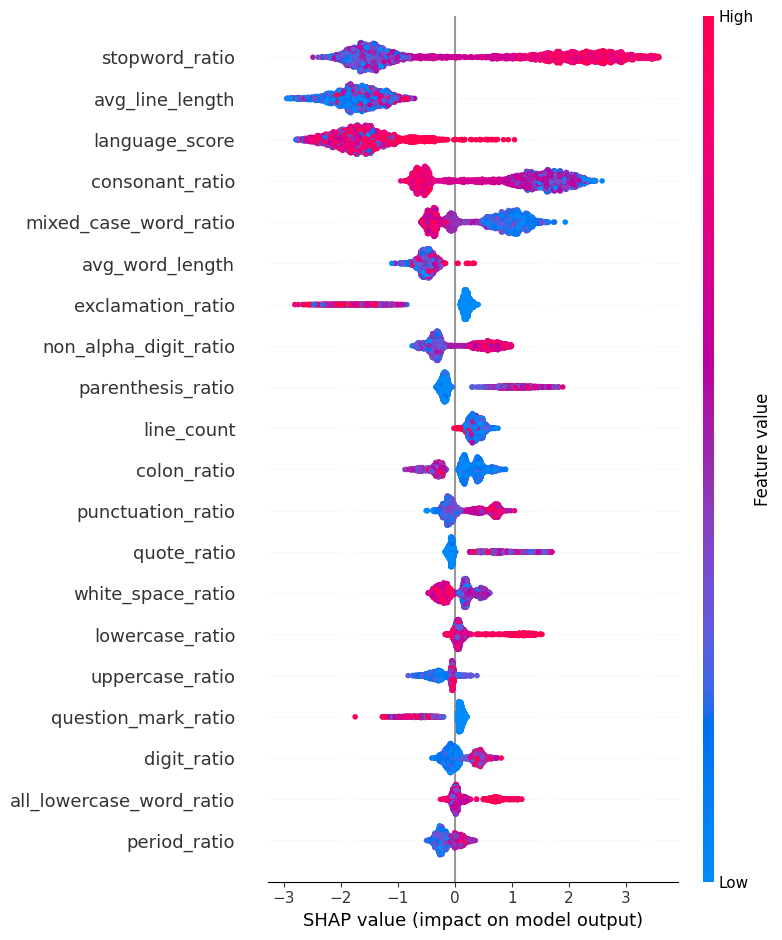

In [ ]:
import shap

# model = modello LGBM già addestrato
model = classifier.model
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_scaled)
shap_values_good = shap_values[1]
shap_values_bad = shap_values[0]

shap.summary_plot(shap_values, X_scaled)


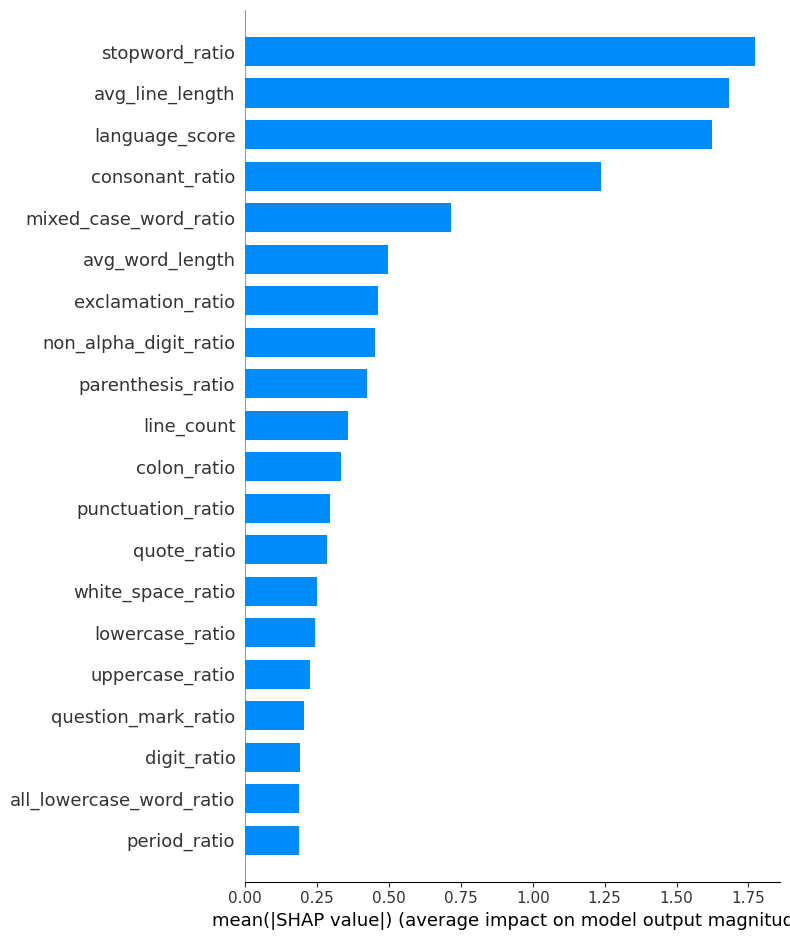

In [ ]:
shap.summary_plot(shap_values, X_scaled, plot_type="bar")